In [5]:
import tensorflow as tf
tf.random.set_seed(101)
import numpy as np
np.random.seed(101)


import keras
keras.backend.clear_session()
from random import choice
import os
import seaborn as sns
from adjustText import adjust_text
import argparse
import json

import pandas as pd
import sys
from datetime import datetime
import matplotlib.pyplot as plt
from tensorflow.keras import optimizers
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.layers import Dense, Layer
import plotly.express as px
#import dash
#import dash_core_components as dcc
#import dash_html_components as html
#from dash.dependencies import Input, Output
import warnings
warnings.filterwarnings('ignore')
from colorama import init, Fore, Style
import plotly.offline as offline
import matplotlib.cm as cm
import matplotlib

## Parámetros

**El código siguiente configura varias variables y rutas de archivo para el modelo de aprendizaje automático**

In [6]:

NUM_GPUS = 1
BS_PER_GPU = 64  # Cantidad de ejemplos por lote por GPU. En este caso, se establece en 64, 
                 # aunque podría ser 128.

# Definición del dispositivo
# device_name = '/gpu:0'  # Si se utiliza una GPU específica
device_name = '/cpu:0'  # Si se utiliza101a CPU

# Configuración de los argumentos de línea de comandos
parser = argparse.ArgumentParser()
parser.add_argument("-d", "--dataset", choices=["chile", "colombia", "lebanon", "georgia"], default="chile", required=False)
parser.add_argument("-e", "--epochs", default=20, type=int, required=False)
parser.add_argument("-m", "--min", default=10, type=int, required=False) # Cantidad minima de votaciones por usuario
parser.add_argument("-ps", "--space", default=2, type=int, required=False)  # Dimension de la capa de embedding. Para coordenadas bidimensionales debe ser 2
parser.add_argument("-s", "--subset", default=999999, type=int, required=False) # Cantidad máxima de usuarios de la base de datos
parser.add_argument("-t", "--type", default="default", type=str, required=False) # Tipo de modelo en la arquitectura. Como se definieron las funciones con los parámetros que estaban por defecto, este parámetro no se utiliza.
parser.add_argument("-f", required=False)
args = parser.parse_args()


# Asignación de los argumentos a variables correspondientes
DATASET = args.dataset
NUM_EPOCHS = args.epochs
MINIMUM_NUMBER_VOTES = args.min
NUMBER_SELECTED_USERS = args.subset
DIM_POLITICAL_SPACE = args.space 
MODEL_TYPE = args.type

# Diccionario para las propiedades del modelo
now = datetime.now()
dateString = now.strftime('%d/%m/%Y %H:%M:%S').replace(' ', '_').replace('/', '_').replace(':', '_')
MODEL_LABEL = f'{DATASET}_{dateString}'  # Nombre con el que se guardará el modelo

# Configuración de rutas de salida 
model_properties_path = f'results/models/model_properties_{MODEL_LABEL}.json'
model_properties = {'model_label': MODEL_LABEL, 'dateString': dateString, 'DATASET': DATASET}

trained_model_path = f'results/models/model_{MODEL_LABEL}'
option_map_path = f'results/models/optionMap_{MODEL_LABEL}.csv'
coordsP_path = f'results/coordsP/{MODEL_LABEL}.csv'
coordsU_path = f'results/coordsU/{MODEL_LABEL}.csv'

# Diccionario para las propiedades del modelo
model_properties['trained_model_path'] = trained_model_path
model_properties['option_map_path'] = option_map_path
model_properties['coordsP_path'] = coordsP_path
model_properties['coordsU_path'] = coordsU_path  

model_properties['NUMBER_SELECTED_USERS'] = NUMBER_SELECTED_USERS
model_properties['MINIMUM_NUMBER_VOTES'] = MINIMUM_NUMBER_VOTES
model_properties['NUM_GPUS'] = NUM_GPUS
model_properties['BS_PER_GPU'] = BS_PER_GPU
model_properties['NUM_EPOCHS'] = NUM_EPOCHS


print('------')
print('MODEL_LABEL:', MODEL_LABEL)
print('Model properties path:', model_properties_path)
print('Proposal Coordinates path:', coordsP_path)
print('User Coordinates path:', coordsU_path)
print('------')


------
MODEL_LABEL: chile_09_03_2026_21_09_12
Model properties path: results/models/model_properties_chile_09_03_2026_21_09_12.json
Proposal Coordinates path: results/coordsP/chile_09_03_2026_21_09_12.csv
User Coordinates path: results/coordsU/chile_09_03_2026_21_09_12.csv
------


## Lectura de datos

**Lectura del archivo que contiene información de votaciones.**

In [8]:
# Lectura del archivo con la información de las votaciones
path = f"../data/data_survey_dump_{DATASET}.csv"  # Ruta del archivo de datos basada en el conjunto de datos seleccionado

# chunksize se refiere a cuántas filas por segundo pandas lee del archivo en cada iteración
data = pd.read_csv(path, chunksize=10**5)  # Lectura del archivo en bloques de 100,000 filas
data = pd.concat(data)  # Concatenación de los bloques de datos en un solo DataFrame
len(data['uuid'].unique())

128501

**Inicialmente hay un total de 128.501 usuarios únicos**

## Preprocesamiento

**0. Convierte la columna de fecha y hora al formato de fecha y hora**

In [9]:
# Convertir la columna "datetime" a formato datetime
data["datetime"] = pd.to_datetime(data["datetime"].str[0:19], format="%Y-%m-%d %H:%M:%S")

# Ordenar los datos por la columna "datetime"
data = data.sort_values("datetime")

**1. Se selecciona el primer ciclo**

In [10]:
def filter_by_cycle(df, cycle):
        """
        Filters data by wave of voting.
        Only valid in the case of Chilecracia.
        """
        path = (f"../Libreria/chile_cycles.csv")
        df_cycles = pd.read_csv(path)
        # Fechas menores al rango definido [X, Y[
        cycle_range = {
            "cycle_1": ["2019-10-24 11:35:05", "2019-10-31 01:35:54"],
            "cycle_2": ["2019-10-31 01:35:54", "2019-11-07 00:55:15"],
            "cycle_3": ["2019-11-07 00:55:15", "2019-11-14 13:10:08"],
            "cycle_4": ["2019-11-14 13:10:08", "2019-11-28 15:21:02"],
            "cycle_5": ["2019-11-28 15:21:02", "2099-12-31 23:59:59"]
        }
        selected = cycle_range[cycle] or cycle_range["cycle_1"]

        ids = df_cycles[df_cycles[cycle] == 1]["id"].unique()
        return df[(df["option_a"].isin(ids)) & (df["option_b"].isin(ids))\
                  & (df["datetime"] >= pd.Timestamp(selected[0])) & (df["datetime"] < pd.Timestamp(selected[1]))]
    
    
    
data = filter_by_cycle(data, 'cycle_1')

**2. Remueve los valores NaN**

In [11]:
# Filtrar filas que contienen valores no nulos en las columnas "option_a" y "option_b"
data = data[(data["option_a"].notna()) & (data["option_b"].notna())].reset_index(drop=True)

# Convertir las columnas "option_a", "option_b" y "selected" a tipo entero
cols = ["option_a", "option_b", "selected"]
data[cols] = data[cols].astype(int)

**3. Elimina usuarios con menos de < THRESHOLD_MIN_USER > votos en la plataforma.**

In [12]:
# Crear un DataFrame temporal llamado df_temp con las columnas "id" y "uuid" del DataFrame data
df_temp = data[["id", "uuid"]]

# Agrupar el DataFrame df_temp por "uuid" y contar el número de ocurrencias de "id"
df_temp = df_temp.groupby(["uuid"]).agg({"id": "count"}).reset_index()

# Filtrar las filas en df_temp para incluir solo aquellos "uuid" con un número de ocurrencias mayor o igual a MINIMUM_NUMBER_VOTES
df_temp = df_temp[df_temp["id"] >= MINIMUM_NUMBER_VOTES]

# Extraer los "uuid" válidos como un arreglo de valores únicos
valid_uuid = df_temp["uuid"].unique()

# Filtrar el DataFrame data para incluir solo las filas con "uuid" en valid_uuid y crear una copia del DataFrame resultante
data = data[data["uuid"].isin(valid_uuid)].copy()

# Se imprime la cantidad de usuarios únicos
len(data['uuid'].unique())

50061

**Después de aplicar este filtro, se observa una disminución a 50,061 usuarios únicos.**

**4. Crea una nueva columna llamada "card_id". Formato: 1 + < id_de_propuesta > + < id_de_propuesta >.**

**Cada <proposal_id> incluye 3 dígitos.**

In [13]:
# Extraer los valores de las columnas "option_a", "option_b" y "selected" del DataFrame data y almacenarlos en la variable a
a = data[["option_a", "option_b", "selected"]].values

# Ordenar las opciones, siempre colocando el valor más bajo en la columna izquierda
data["option_a_sorted"] = np.where(a[:, 0] < a[:, 1], a[:, 0], a[:, 1])
data["option_b_sorted"] = np.where(a[:, 0] >= a[:, 1], a[:, 0], a[:, 1])

# Generar un ID de tarjeta
data["card_id"] = "1" + data["option_a_sorted"].astype(str).str.zfill(3) + data["option_b_sorted"].astype(str).str.zfill(3)
data["card_id"] = data["card_id"].astype(int)

**5. Incluye una nueva columna llamada "latest". Esta columna filtra las votaciones duplicadas de un usuario sobre un par de propuesta y selecciona la última votación registrada para dicho par.**

In [14]:
# Ordena los datos por datetime de los clics realizados en el dataset
data = data.sort_values(["id", "datetime"])

# Extrae las columnas "uuid", "card_id", "datetime" y "id" del DataFrame data y las almacena en la variable u
u = data[["uuid", "card_id", "datetime", "id"]]

# Agrupa los datos por "datetime", "uuid", "card_id" y "id" y cuenta las ocurrencias, luego reinicia los índices
u = u.groupby(["datetime", "uuid", "card_id", "id"]).count().reset_index()

# Elimina duplicados de "uuid" y "card_id" manteniendo solo las últimas ocurrencias, y elimina las columnas "datetime", "uuid" y "card_id"
u = u.drop_duplicates(["uuid", "card_id"], keep="last").drop(columns=["datetime", "uuid", "card_id"])

# Agrega una columna "latest" con valor 1 a los datos del DataFrame data
u["latest"] = 1

# Une los datos originales del DataFrame data con los datos en el DataFrame u, utilizando la columna "id" como clave y manteniendo todos los registros de data
data = pd.merge(data, u, on="id", how="left")

# Reemplaza los valores nulos de la columna "latest" con 0 en el DataFrame data
data.loc[data["latest"].isna(), "latest"] = 0

# Convierte la columna "latest" en tipo entero en el DataFrame data
data["latest"] = data["latest"].astype(int)

# Selecciona solo las últimas votaciones de todos los usuarios, es decir, donde la columna "latest" es igual a 1, y crea una copia del DataFrame data
data = data[data["latest"] == 1].copy()

**6. Se une con la información con el archivo de predicciones de bots y se filtran los clasificados como bots**

In [15]:
# Se define el path al archivo de predicciones de bots
path_bots =  f"../results/bot_prediction/{DATASET}_uuid.csv"

# Se lee el archivo de predicciones de bots en chunks de tamaño 10^5 y se guarda en BOT_LIST
BOT_LIST = pd.read_csv(path_bots, chunksize=10**5)

# Se concatenan los chunks de BOT_LIST en un solo DataFrame
BOT_LIST = pd.concat(BOT_LIST)

# Se fusionan los datos del DataFrame data con los datos del DataFrame BOT_LIST 
data = pd.merge(data, BOT_LIST, on="uuid")

# Se filtran los usuarios bots
df_filter = data["prediction"] == 0
dfRaw = data[df_filter]


FileNotFoundError: [Errno 2] No such file or directory: '../results/bot_prediction/chile_uuid.csv'

**7. Se filtran las votaciones que no tuvieron preferencia**

In [16]:
# Se crea una copia del DataFrame dfRaw
df = dfRaw[dfRaw.columns]

# Se filtran los datos en df donde la columna 'selected' no es igual a 0
df = df[df['selected'] != 0]

# Se filtran los datos en df donde la columna 'uuid' no es nula
df = df[~df['uuid'].isna()]

# Se printea la cantidad de usuarios únicos
len(df['uuid'].unique())

NameError: name 'dfRaw' is not defined

**Con la aplicación de estos filtros, la cantidad de votantes únicos se reduce a 48,119.**

## División base de datos

**Funciones utilizadas para dividir la base de datos de entrenamiento y prueba**

In [12]:
def makeX(uuid,a,b,optionMap,userMap):
    return (list(optionMap[a])+list(userMap[uuid])+list(optionMap[b]))

def formatData(df, testFraction=0.1, method='index', path=None, optionMap=None):
    '''
    Realiza la división de los datos en conjuntos de entrenamiento y prueba.
     
    Parameters
    ----------
    df: pandas.DataFrame
        Tabla con columnas: uuid, option_a, option_b, selected.
        Genera la variable Y (indica si selected == option_a).

    testFraction: float
        Fracción de datos que se dejará para la prueba.

    path: str (opcional)
        Si no es None, guarda el optionMap en la ruta especificada como un archivo csv.
        Por favor, agregar la extensión csv.
    '''

    # Conjunto de opciones y usuarios únicos en el DataFrame
    optionSet = set(df['option_a']) | set(df['option_b'])
    userSet = set(df['uuid'])

    # Número de opciones y usuarios únicos
    nOptions = len(optionSet)
    nUsers = len(userSet)

    # Generar la variable de resultado Y. Es 1 si la opción seleccionada es a, 0 si es b.
    if 'Y' not in df.columns:
        df['Y'] = 0  # La variable de resultado es 0.
        df.loc[df['selected'] == df['option_a'], 'Y'] = 1

    # Generar un mapa de las propuestas en relación a su indice
    if optionMap is None:
        optionMap = {o: [i] for i, o in enumerate(sorted(list(optionSet)))}
    userMap = {o: [i] for i, o in enumerate(sorted(list(userSet)))}

    # Guardar el optionMap en un archivo CSV si se especifica una ruta (path)
    if (path is not None) and (method == 'index'):
        optionMapDf = pd.DataFrame([(o, optionMap[o][0]) for o in optionMap], columns=['option', 'index'])
        optionMapDf.to_csv(path, index=False)

    # Crear la matriz X con listas [[option a],[uuid],[óption b]]
    # y el vector Y con 1 si la opción seleccionada es a, y 0 caso contrario.
    X = [makeX(uuid, a, b, optionMap, userMap) for uuid, a, b in df[['uuid', 'option_a', 'option_b']].values]
    X = np.array(X)
    Y = df['Y'].values

    # A continuación se dividirá aleatoriamente los datos en entrenamiento y prueba
    # Inicializar dos listas vacías para almacenar los indices de los registros de entrenamiento y prueba
    id_test = []
    id_train = []
    # Agrupar el conjunto de datos por la columna "uuid"
    df = df.reset_index()
    df_user_a = df.groupby('uuid')

    # Iterar sobre cada grupo de usuario
    for name, df_user in df_user_a:

        # Se guarda y mezcla de manera aleatoria los indices de cada usuario.
        i = np.array(df_user.index)
        #np.random.shuffle(i)

        # Dividir el arreglo en dos subconjuntos, uno para entrenamiento y otro para prueba, con una proporción según el valor
        # de testFraction.
        train, test = np.split(i, [int(len(i) * (1-testFraction))])

        # Agregar los indices correspondientes a los registros de entrenamiento y prueba a las listas
        id_train.append(train)
        id_test.append(test)



    # Aplanar las listas de indices de registros de entrenamiento y prueba
    id_train = [item for sublist in id_train for item in sublist]
    id_test = [item for sublist in id_test for item in sublist]

    
    # Se separa la base de entrenamiento y test según los indices que contienen id_train y id_test.
    X_test = X[id_test]
    Y_test = Y[id_test]
    X = X[id_train]
    Y = Y[id_train]

    return X, Y, X_test, Y_test, optionMap, userMap


**A continuación se separan los datos en entrenamiento y testeo. Se utiliza un 10% para la base de testeo. La estructura definida para los datos de entrada a la red es de la forma [option_a, uuid , option_b].**

In [13]:
# Prepara los datos para tensorflow

print('Formateando los datos para TensorFlow')
nOptions = len(set(df['option_a']) | set(df['option_b']))  # Número total de opciones
nUsers = len(set(df['uuid']))  # Número de usuarios
model_properties['nOptions'] = nOptions
model_properties['nUsers'] = nUsers

# Divide la base de datos de entrenamiento y test. Con el parámetro testFraction se define las proporciones del tamaño
# de la base de test.
X, Y, X_test, Y_test, optionMap, userMap = formatData(df, testFraction=0.1, method='index', path=option_map_path)


SIZE_INPUT_LAYER = np.shape(X)[-1]
NUM_TRAIN_SAMPLES = len(Y)

# Se convierte los tensores X e Y en un dataset que puede ser utilizado para alimentar los datos
# al modelo de TensorFlow durante el entrenamiento y la evaluación.
train_dataset = tf.data.Dataset.from_tensor_slices((X, Y))
# Se mezcla el dataset de entrenamiento y se dividen en lotes de tamaño
train_dataset = train_dataset.shuffle(NUM_TRAIN_SAMPLES).batch(BS_PER_GPU * NUM_GPUS, drop_remainder=True).repeat()

# Se realiza el mismo procedimiento para la base de test.
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, Y_test))
test_dataset = test_dataset.batch(BS_PER_GPU * NUM_GPUS, drop_remainder=True).repeat()


Formateando los datos para TensorFlow


**La base de datos utilizada para el entrenamiento y la prueba tiene la siguiente estructura:**

1. **X**: Es la entrada de la red. Cada elemento se compone de la forma [opción a, uuid, opción b].
2. **Y**: Es la salida de la red. Cada elemento corresponde a un 0 o 1. Si es 1, la opción seleccionada es "a", mientras que si es 0, la opción seleccionada es "b".

**A continuación, se presentará un ejemplo de los primeros elementos que presentan los datos de entrada y salida.**

In [14]:
print('\033[1m'+'Entrenamiento:'+'\033[0m')
print('\033[1m'+'X:'+'\033[0m'+str(X[0]))
print('\033[1m'+'Y: '+'\033[0m'+str(Y[0]))
print('')
print('\033[1m'+'Test:'+'\033[0m')
print('\033[1m'+'X_test:'+'\033[0m'+str(X_test[0]))
print('\033[1m'+'Y_test: '+'\033[0m'+str(Y_test[0]))

Entrenamiento:
X:[86  0 43]
Y: 0

Test:
X_test:[46  0 62]
Y_test: 1


## Arquitectura del modelo

**A continuación se definen clases para construir la arquitectura del modelo: PoliticalCoords, la cual corresponde a la primera capa de la arquitectura;NOM, correspondiente a la segunda capa.**

In [15]:
# Clase de la primera capa de la arquitectura
class PoliticalCoords(Layer):
    def __init__(self,dimPoliticalSpace=2, nOptions=90, nUsers=100, activation='linear', initializer_stddev=0.05, initializer_seed=101):
        '''
        Toma una capa con índices.
        Supone que la entrada está ordenada como Opción A, Usuario, Opción B.
        Retorna en el mismo orden.

        Parámetros
        ----------
        initializer_stddev: float (default=0.05)
            Las coordenadas se inicializan utilizando un inicializador random_normal con media cero. 
            Este parámetro establece la desviación estándar.
        initializer_seed: int (default=101)
            Semilla del inicializador para asegurar consistencia en la comparación entre modelos.
        '''
        super(PoliticalCoords, self).__init__()


        self.nOptions           = nOptions
        self.nUsers             = nUsers
        self.activation         = activation
        self.dimPoliticalSpace  = dimPoliticalSpace
        self.initializer_seed   = initializer_seed
        self.initializer_stddev = initializer_stddev

        wp_init = tf.random_normal_initializer(mean=0.0, stddev=self.initializer_stddev, seed=self.initializer_seed)
        wu_init = tf.random_normal_initializer(mean=0.0, stddev=self.initializer_stddev, seed=self.initializer_seed)
        self.wp = tf.Variable(initial_value=wp_init(shape=(self.nOptions, self.dimPoliticalSpace),dtype='float32'),
                         trainable=True)
        self.wu = tf.Variable(initial_value=wu_init(shape=(self.nUsers, self.dimPoliticalSpace),dtype='float32'),
                         trainable=True)

    def call(self, inputs):
        """
        Realiza el cálculo de la coordenadas politicas utilizando una capa de embedding.
        """
        
        inputs = tf.cast(inputs,'int32')
        za = tf.nn.embedding_lookup(self.wp, inputs[:,:1])[:,0,:]
        zu = tf.nn.embedding_lookup(self.wu, inputs[:,1:2])[:,0,:]
        zb = tf.nn.embedding_lookup(self.wp, inputs[:,2:])[:,0,:]
        z = tf.concat([za,zu,zb],1)
        return tf.nn.sigmoid(z)

    def returnOptionsEmbedding(self, withActivation=True):
        '''
        Devuelve las coordenadas políticas de las opciones.
        '''
        z = self.wp
        return tf.nn.sigmoid(z)

    def returnUsersEmbedding(self, withActivation=True):
        '''
        Devuelve las coordenadas políticas de los usuarios.
        '''
        z = self.wu     
        return tf.nn.sigmoid(z)
    
    
class NOM_original(Layer):
    def __init__(self, dimPoliticalSpace=32,  symmetric=True, neuronas=10, initializer_stddev = 0.05,initializer_seed=101):
        '''
        Implementa la función NOMINATE como una suma ponderada de las distancias.
        Se asume que la entrada está ordenada como Opción A, Usuario, Opción B.
        Esta capa debe estar conectada a la capa PoliticalCoords.
        Esta capa siempre devolverá un tensor de forma (1,2), independientemente de la dimensión 
        del espacio político.

        Parameters
        ----------
        dimPoliticalSpace: int
            Dimensión del espacio de coordenadas políticas (dimensión del embedding).
        activation: str
            Función de activación. El NOMINATE estándar utiliza 'exp'.
        symmetric: booleano (default=True)
            Si es False, la métrica del espacio político será diferente al comparar A con U 
            que al comparar U con A.
        weightsType: str ('linear', 'square', o None)
            Tipo de pesos a utilizar como métrica para el espacio político. Si es None, se asume
            que el espacio político es plano.
        '''
        super(NOM_original, self).__init__()    

        self.dimPoliticalSpace = dimPoliticalSpace
        self.neuronas          = neuronas
        self.symmetric         = symmetric
        self.initializer_seed  = initializer_seed
        self.initializer_stddev = initializer_stddev
        
        
        if self.symmetric:
            if neuronas%2!=0:
                print('Neuronas debe ser par')
        
            w_init = tf.random_normal_initializer(seed=self.initializer_seed,stddev=self.initializer_stddev,)
            self.w = tf.Variable(initial_value=w_init(shape=(dimPoliticalSpace, int(neuronas/2)),dtype='float32'),
                                  trainable=True)
            b_init = tf.random_normal_initializer(seed=self.initializer_seed)
            self.b = tf.Variable(initial_value=b_init(shape=(1,int(neuronas/2)),dtype='float32'),
                                 trainable=True)
        
        else:
            wa_init = tf.random_normal_initializer(seed=self.initializer_seed,stddev=self.initializer_stddev)
            self.wa = tf.Variable(initial_value=wa_init(shape=(dimPoliticalSpace, int(neuronas/2)),dtype='float32'),
                              trainable=True)
            wb_init = tf.random_normal_initializer(seed=self.initializer_seed,stddev=self.initializer_stddev)
            self.wb = tf.Variable(initial_value=wb_init(shape=(dimPoliticalSpace, int(neuronas/2)),dtype='float32'),
                                      trainable=True)
            b_init = tf.random_normal_initializer(seed=self.initializer_seed,stddev=self.initializer_stddev)
            self.b = tf.Variable(initial_value=b_init(shape=(1,neuronas),dtype='float32'),
                         trainable=True)

   
       
    def call(self, inputs):
        """
        Realiza el cálculo de la función NOMINATE para una entrada dada  utilizando las coordenadas
        políticas, los pesos y los términos de sesgo definidos en la capa. El procedimiento consiste
        en tomar las coordenadas políticas de la opción A, el usuario y la opción B, y calcular las
        distancias al usuario. Luego, se realiza una multiplicación matricial con los pesos w, se 
        realiza una concatenación y se agrega un término de sesgo b. Finalmente, se aplica la función
        de activación exponencial (exp) a la salida.
        """
        xa = inputs[:,:self.dimPoliticalSpace]
        xu = inputs[:,self.dimPoliticalSpace:self.dimPoliticalSpace*2]
        xb = inputs[:,self.dimPoliticalSpace*2:]

        da = tf.math.square(tf.math.subtract(xa,xu))
        db = tf.math.square(tf.math.subtract(xb,xu))

        if self.symmetric:
          
            za = tf.matmul(da, self.w)
            zb = tf.matmul(db, self.w)
            z = tf.concat([za,zb],1) 
            z = z +  tf.concat([self.b,self.b],1) 
        else:
           
            za = tf.matmul(da, self.wa)
            zb = tf.matmul(db, self.wb)
            z = tf.concat([za,zb],1) + self.b
        return tf.exp(z)

    def returnSpaceWeights(self):
        '''
        Devuelve las coordenadas políticas de las propuestas
        '''
        if self.symmetric:
            return self.w
        else:
            return [self.wa,self.wb]


          
class DENSE_original(Layer):
    def __init__(self,neuronas=10, symmetric=True, initializer_seed=101):
        '''
        Implementa la función NOMINATE como una suma ponderada de las distancias.
        Se asume que la entrada está ordenada como Opción A, Usuario, Opción B.
        Esta capa debe estar conectada a la capa PoliticalCoords.
        Esta capa siempre devolverá un tensor de forma (1,2), independientemente de la dimensión 
        del espacio político.

        Parameters
        ----------
        dimPoliticalSpace: int
            Dimensión del espacio de coordenadas políticas (dimensión del embedding).
        activation: str
            Función de activación. El NOMINATE estándar utiliza 'exp'.
        symmetric: booleano (default=True)
            Si es False, la métrica del espacio político será diferente al comparar A con U 
            que al comparar U con A.
        weightsType: str ('linear', 'square', o None)
            Tipo de pesos a utilizar como métrica para el espacio político. Si es None, se asume
            que el espacio político es plano.
        '''
        super(DENSE_original, self).__init__()    


        self.symmetric         = symmetric
        self.neuronas          = neuronas
        self.initializer_seed  = initializer_seed
        
        if neuronas%2!=0:
            print('Neuronas tiene que ser par')
        
        if self.symmetric:

            w_init = tf.random_normal_initializer(seed=self.initializer_seed)
            self.w = tf.Variable(initial_value=w_init(shape=(int(neuronas/2), 1),dtype='float32'),
                                  trainable=True)
            b_init = tf.random_normal_initializer(seed=self.initializer_seed)
            self.b = tf.Variable(initial_value=b_init(shape=(1,1),dtype='float32'),
                                 trainable=True)
        
        else:
            wa_init = tf.random_normal_initializer(seed=self.initializer_seed)
            self.wa = tf.Variable(initial_value=wa_init(shape=(int(neuronas/2), 1),dtype='float32'),
                              trainable=True)
            wb_init = tf.random_normal_initializer(seed=self.initializer_seed)
            self.wb = tf.Variable(initial_value=wb_init(shape=(int(neuronas/2), 1),dtype='float32'),
                                      trainable=True)
            b_init = tf.random_normal_initializer(seed=self.initializer_seed)
            self.b = tf.Variable(initial_value=b_init(shape=(1,2),dtype='float32'),
                         trainable=True)

    def call(self, inputs):
        """
        Realiza el cálculo de la función NOMINATE para una entrada dada  utilizando las coordenadas
        políticas, los pesos y los términos de sesgo definidos en la capa. El procedimiento consiste
        en tomar las coordenadas políticas de la opción A, el usuario y la opción B, y calcular las
        distancias al usuario. Luego, se realiza una multiplicación matricial con los pesos w, se 
        realiza una concatenación y se agrega un término de sesgo b. Finalmente, se aplica la función
        de activación exponencial (exp) a la salida.
        """
        da = inputs[:,:int(self.neuronas/2)]
        db = inputs[:,int(self.neuronas/2):]


        if self.symmetric:
          
            za = tf.matmul(da, self.w)
            zb = tf.matmul(db, self.w)
            z = tf.concat([za,zb],1) 
            z = z +  tf.concat([self.b,self.b],1) 
        else:
           
            za = tf.matmul(da, self.wa)
            zb = tf.matmul(db, self.wb)
            z = tf.concat([za,zb],1) + self.b
        return tf.exp(z)

    def returnSpaceWeights(self):
        '''
        Devuelve las coordenadas políticas de las propuestas
        '''
        if self.symmetric:
         
            return self.w
        else:
           
            return [self.wa,self.wb]
       
    

def get_model_original(model_type=None, dimPoliticalSpace=2, nOptions=90, nUsers=100):
    '''
    Arquitectura compuetsa por una capa de embedding, capa oculta de 8 neuronas, capa oculpta de 2 neuronas y una capa de salida
    de una neurona.
    Parámetros
    ----------
    model_type: str (opcional)
        Podemos definir múltiples modelos y seleccionarlos con este parámetro.
    '''
    model = Sequential([
        PoliticalCoords(nOptions=nOptions, nUsers=nUsers, dimPoliticalSpace=dimPoliticalSpace, activation='sigmoid', initializer_stddev=0.05),
        NOM_original(dimPoliticalSpace=dimPoliticalSpace, neuronas =8, symmetric=True),
        DENSE_original(neuronas=8, symmetric=True),
        Dense(1, activation='sigmoid'),
    ])
  
    return model
                          
     


**La arquitectura del modelo consiste en 3 etapas:**

    1. PoliticalCoords: Capa de embedding que transforma la entrada en cordenadas de dimensión  
       DIM_POLITICAL_SPACE.

    2. NOM: En esta capa, se implementa la función nominal a través de la ponderación combinada de distancias. Se presupone que la entrada está organizada en el orden de Opción A, Usuario y Opción B. Esta capa oculta se encuentra conectada con la capa "PoliticalCoords". Con un total de N neuronas, se distribuye 4 neuronas para procesar exclusivamente la suma ponderada de las distancias entre la Opción A y los usuarios. Las 4 neuronas restantes se enfocan en procesar la suma ponderada de las distancias entre la Opción B y los usuarios.
    
    3. Capa oculta del modelo original con 2 neuronas
    
    4. Capa densa que transforma la salida de NOM en una probabilidad. La probabilidad de acerca a 1 cuando la opción seleccionada es a), mientras que la probabilidad de acerca a 0 cuando la propuesta seleccionada es la opción b).


In [16]:
print('Preparing model')
model_properties['DIM_POLITICAL_SPACE'] = DIM_POLITICAL_SPACE 
model_properties['model_type'] = MODEL_TYPE

# Se define el modelo
model = get_model_original(model_type=MODEL_TYPE, dimPoliticalSpace=DIM_POLITICAL_SPACE, nOptions=nOptions, nUsers=nUsers)


Preparing model


## Entrenamiento

**A continuación se compila y entrena el modelo**

In [17]:
adamax_opt = tf.keras.optimizers.experimental.Adamax(learning_rate=0.01)

with tf.device(device_name):
    model.compile(
        loss=tf.keras.losses.BinaryCrossentropy(),  # Función de pérdida para el problema de clasificación binaria
        optimizer=adamax_opt,  # Optimizador Adam con los parámetros de aprendizaje especificados
        metrics=['accuracy']  # Métricas a utilizar, en este caso, precisión (accuracy)
    )

    history = model.fit(
        train_dataset,  # Conjunto de entrenamiento
        epochs=NUM_EPOCHS,  # Número de épocas de entrenamiento
        steps_per_epoch=NUM_TRAIN_SAMPLES // BS_PER_GPU,  # Número de pasos por época
        validation_steps=len(Y_test) // BS_PER_GPU,  # Número de pasos de validación
        validation_data=test_dataset,  # Conjunto de validación
        verbose=2 # Nivel de detalle de los mensajes de entrenamiento
    )
    


Epoch 1/20
41929/41929 - 85s - loss: 0.6116 - accuracy: 0.6595 - val_loss: 0.6019 - val_accuracy: 0.6734 - 85s/epoch - 2ms/step
Epoch 2/20
41929/41929 - 96s - loss: 0.5761 - accuracy: 0.6973 - val_loss: 0.5856 - val_accuracy: 0.6894 - 96s/epoch - 2ms/step
Epoch 3/20
41929/41929 - 108s - loss: 0.5602 - accuracy: 0.7103 - val_loss: 0.5804 - val_accuracy: 0.6937 - 108s/epoch - 3ms/step
Epoch 4/20
41929/41929 - 120s - loss: 0.5542 - accuracy: 0.7150 - val_loss: 0.5779 - val_accuracy: 0.6961 - 120s/epoch - 3ms/step
Epoch 5/20
41929/41929 - 128s - loss: 0.5512 - accuracy: 0.7171 - val_loss: 0.5773 - val_accuracy: 0.6955 - 128s/epoch - 3ms/step
Epoch 6/20
41929/41929 - 141s - loss: 0.5494 - accuracy: 0.7181 - val_loss: 0.5781 - val_accuracy: 0.6947 - 141s/epoch - 3ms/step
Epoch 7/20
41929/41929 - 155s - loss: 0.5484 - accuracy: 0.7187 - val_loss: 0.5790 - val_accuracy: 0.6944 - 155s/epoch - 4ms/step
Epoch 8/20
41929/41929 - 166s - loss: 0.5477 - accuracy: 0.7189 - val_loss: 0.5779 - val_accur

## Evaluación

In [18]:
print('EVALUATE MODEL')

# Evaluar el modelo en el conjunto de datos de prueba
eva = model.evaluate(test_dataset, steps=len(Y_test) // BS_PER_GPU)

# Imprimir el puntaje de prueba y la precisión de prueba
print('Test Score: ', eva[0])
print('Test accuracy: ', eva[1])

# Guardar los valores de pérdida y precisión en las propiedades del modelo
model_properties['TEST_SCORE'] = float(str(eva[0]))
model_properties['TEST_ACCURACY'] = float(str(eva[1]))


EVALUATE MODEL
5066/5066 [==============================] - 8s 2ms/step - loss: 0.5835 - accuracy: 0.6919
Test Score:  0.583482563495636
Test accuracy:  0.6918858289718628


**A continuación se realiza la visualización del modelo y se muestra un resumen del mismo.**

In [19]:
tf.keras.utils.plot_model(model, f'results/figures/sequential_{DATASET}_{dateString}.png', show_shapes=True)
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 political_coords (Political  (64, 6)                  96418     
 Coords)                                                         
                                                                 
 nom_original (NOM_original)  (64, 8)                  12        
                                                                 
 dense_original (DENSE_origi  (64, 2)                  5         
 nal)                                                            
                                                                 
 dense (Dense)               (64, 1)                   3         
                                                                 
Total params: 96,438
Trainable params: 96,438
Non-trainable params: 0
_________________________________________________________________


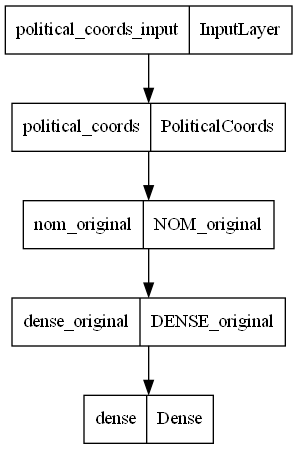

In [20]:
from keras.utils.vis_utils import plot_model
plot_model(model)

**Se procederá a extraer y guardar la información de las coordenadas políticas de los usuarios y propuestas, así como los valores de los pesos del modelo.**

In [21]:
print('Saving values')

# Crear DataFrame de mapeo de índices de opciones
optionIndex = pd.DataFrame([(i, optionMap[i][0]) for i in optionMap], columns=['option_id', 'index'])
# Crear DataFrame de mapeo de índices de usuarios
userIndex = pd.DataFrame([(i, userMap[i][0]) for i in userMap], columns=['uuid', 'index'])

# Leer metadatos de usuarios desde un archivo CSV
userMetadata = pd.read_csv(f'../data/data_people_dump_{DATASET}.csv')

# Leer metadatos de propuestas desde un archivo CSV o TSV
propsMetadata = pd.read_csv(f'../data/labels/{DATASET}.tsv', delimiter='\t').rename(columns={'id': 'option_id'})

# Obtener las coordenadas de las propuestas del modelo
coordsP = model.layers[0].returnOptionsEmbedding().numpy()
# Combinar las coordenadas con el índice de opciones y convertirlo a DataFrame
coordsP = pd.merge(optionIndex, pd.DataFrame(coordsP, columns=['z' + str(i+1) for i in range(DIM_POLITICAL_SPACE)]).reset_index()).drop('index', 1)

# Obtener las coordenadas de los usuarios del modelo
coordsU = model.layers[0].returnUsersEmbedding().numpy()
# Combinar las coordenadas con el índice de usuarios y convertirlo a DataFrame
coordsU = pd.merge(userIndex, pd.DataFrame(coordsU, columns=['z' + str(i+1) for i in range(DIM_POLITICAL_SPACE)]).reset_index()).drop('index', 1)
# Combinar las coordenadas de usuarios con los metadatos de usuarios
#coordsU = pd.merge(userMetadata, coordsU)

# Guardar las coordenadas de las propuestas en un archivo CSV
coordsP.to_csv(coordsP_path, index=False)
# Guardar las coordenadas de los usuarios en un archivo CSV
coordsU.to_csv(coordsU_path, index=False)

# Guardar los pesos del modelo entrenado
model.save_weights(trained_model_path)

# Guardar las propiedades del modelo en un archivo JSON
model_properties['INITIAL_USER_COORDS'] = model.layers[0].returnUsersEmbedding().numpy().mean(0).tolist()
with open(model_properties_path, 'w') as fp:
    json.dump(model_properties, fp)

Saving values


**En resumen, las salidas del modelo son las siguientes:**

1. Coordenadas bidimensionales de los usuarios y las propuestas.
2. Probabilidad de selección entre la opción "a" y la opción "b". Si la probabilidad es 1, la opción seleccionada es "a"; si es 0, la opción seleccionada es "b".

**Finalmente se grafica el rendimiento del modelo durante el entrenamiento y la validación**

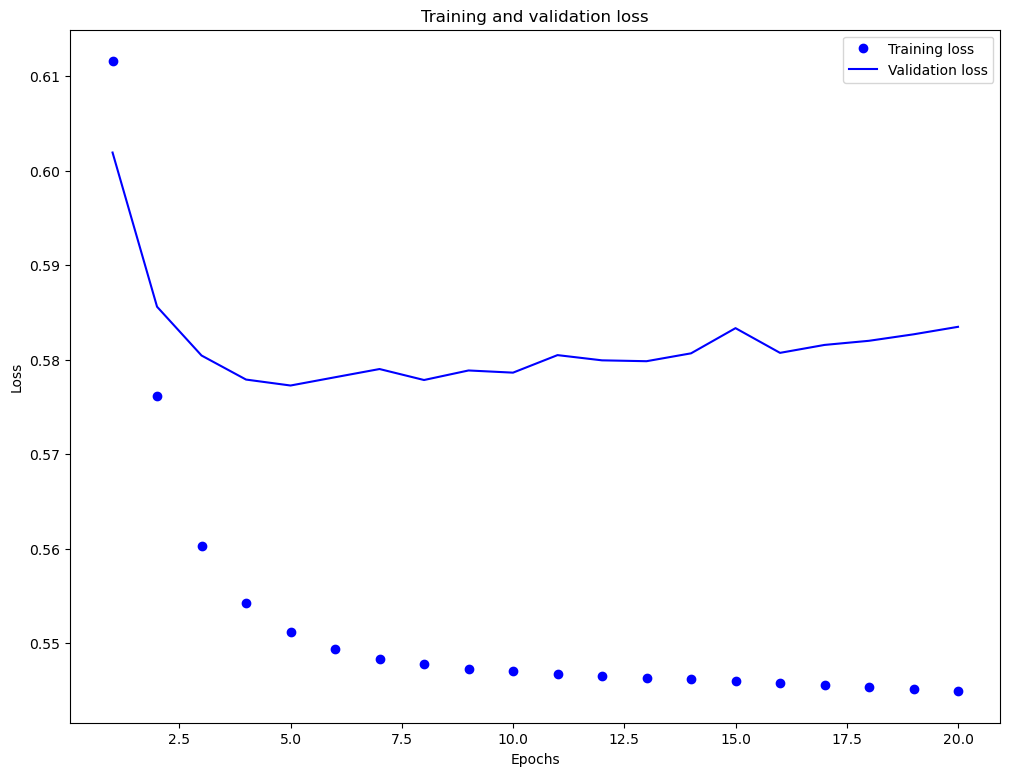

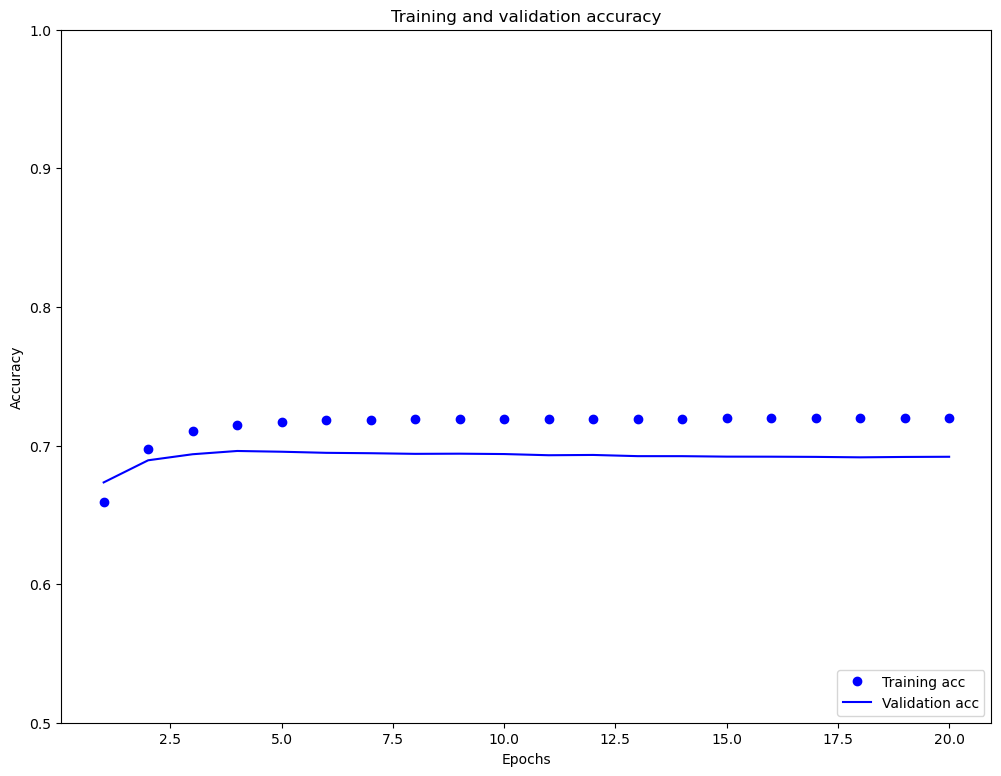

In [22]:
# Obtener los valores del historial de entrenamiento
history_dict = history.history
acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']
epochs = range(1, len(acc) + 1)

# Graficar la pérdida de entrenamiento y validación en función de las épocas
plt.figure(figsize=(12, 9))
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Graficar la precisión de entrenamiento y validación en función de las épocas
plt.figure(figsize=(12, 9))
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.ylim((0.5, 1))
plt.show()


In [35]:
coordsU_path

'results/coordsU/chile_04_01_2024_16_46_41.csv'

## Análisis figuras Nominate

In [ ]:

# Asignación de los argumentos a variables correspondientes
DATASET = 'chile'
# Leer metadatos de usuarios desde un archivo CSV
userMetadata = pd.read_csv(f'../data/data_people_dump_{DATASET}.csv')

# Cargar el archivo CSV de coordenadas las propuestas
coordsP = pd.read_csv('results/coordsP/chile_04_01_2024_16_46_41.csv')

# Cargar el archivo TSV de etiquetas de coordenadas
labels_coords = pd.read_csv(f'../data/labels/chile.tsv', delimiter='\t').rename(columns={'id': 'option_id'})

# Combinar (merge) los DataFrames coordsP y labels_coords en base a la columna 'option_id'
coordsP = coordsP.merge(labels_coords, on='option_id')

# Cargar el archivo CSV de coordenadas Usuarios
coordsU = pd.read_csv('results/coordsU/chile_04_01_2024_16_46_41.csv')
coordsU = pd.merge(userMetadata, coordsU,on='uuid')

**1. Usuarios**

In [ ]:
sns.set(rc={"figure.figsize": (6,6)}, style="whitegrid")
texts = []
ax = sns.scatterplot(x="z2", y="z1",  hue="politica", data=coordsU,palette='Spectral')
plt.title('Distribucion de usuarios')



**Cada usuario ha informado su posición política en una escala del 1 al 10, donde:**

* Valores menores a 5 se asocian con la política de izquierda.
* Valores iguales a 5 se asocian con la política de centro.
* Valores mayores a 5 se asocian con la política de derecha.

**La figura anterior muestra la ubicación de cada usuario, mientras que el color representa su posición política."**




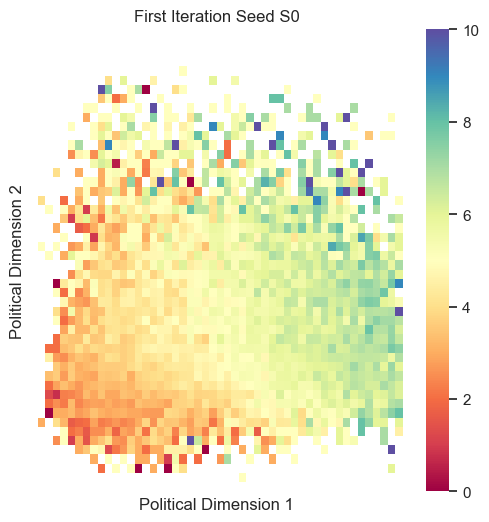

In [26]:
# Se define una función para eliminar las marcas de los ejes en un gráfico
def remove_ticks(ax):
    ax.set_xticks([])       # Eliminar marcas del eje x
    ax.set_yticks([])       # Eliminar marcas del eje y
    ax.set_xlabel("Political Dimension 1")       # Eliminar etiqueta del eje x
    ax.set_ylabel("Political Dimension 2")       # Eliminar etiqueta del eje x


bins = 50                             # Número de intervalos para dividir los datos
interval = [i / bins for i in list(range(0, bins + 1))]   # Cálculo de los intervalos

# Se dividen los datos de la columna "z1" en intervalos y se almacena el resultado en una nueva columna "x_bins"
coordsU["x_bins"] = pd.cut(np.array(coordsU["z2"]), interval)
# Se divide los datos de la columna "z2" en intervalos y se almacena el resultado en una nueva columna "y_bins"
coordsU["y_bins"] = pd.cut(np.array(coordsU["z1"]), interval)

# Agrupar los datos por los intervalos de "x_bins" y "y_bins", y calcular la media de la columna "politica",
x = coordsU.groupby(["x_bins", "y_bins"]).agg({"politica": "mean"}).reset_index()


sns.set(rc={"figure.figsize": (6, 6)}, style="white")

# Se crea un mapa de calor utilizando los valores de "politica" como datos, con los intervalos de "x_bins" en el eje x
# y los intervalos de "y_bins" en el eje y. 
ax = sns.heatmap(x.pivot(index="y_bins", columns="x_bins", values="politica"), cmap="Spectral")

ax.invert_yaxis()     
ax.set_title("First Iteration Seed S0")   
remove_ticks(ax)     

**En el mapa de calor, cada celda representa la media de los valores de "politica" dentro de un intervalo específico. Al analizar la figura, se puede observar una agrupación de usuarios con orientación política de izquierda en el lado izquierdo del mapa, mientras que en el lado derecho se evidencia una agrupación de usuarios con orientación política de derecha.**

**2. Pares de propuestas**

In [27]:
# Crear un gráfico de dispersión interactivo con Plotly
fig = px.scatter(coordsP, x="z1", y="z2", color="topic_name", hover_data=["short_name"])

# Personalizar el diseño del gráfico
fig.update_layout(
    title="Gráfico de Dispersión con Información al Pasar el Mouse",
    xaxis_title="z2",
    yaxis_title="z1",
    legend_title="Topic Name"
)

# Ajustar el tamaño de la leyenda y ubicarla a la derecha
fig.update_layout(
    legend=dict(
        itemsizing='constant',  # Ajusta el tamaño de los elementos de la leyenda
        orientation="v",  # Cambia la orientación de la leyenda a vertical
        yanchor="top",  # Ancla la leyenda en la parte superior
        y=1,  # Ajusta la posición vertical de la leyenda
        xanchor="left",  # Ancla la leyenda a la izquierda
        x=1.02  # Ajusta la posición horizontal de la leyenda
    )
)

# Establecer el tamaño del gráfico para que sea cuadrado sin considerar la leyenda
fig.update_layout(
    autosize=False,
    width=800,  # Ajusta según tus preferencias
    height=600  # Ajusta según tus preferencias
)


# Mostrar el gráfico interactivo
fig.show()
#offline.plot(fig, filename='results/figures/Propuestas_notebook_modificado.html')

In [28]:
import plotly.express as px

# Crear un gráfico de dispersión interactivo con Plotly para cada topic
topic_names =coordsP['topic_name'].unique()
figures = []

for topic_name in topic_names:
    # Crear un gráfico de dispersión interactivo con Plotly para el topic actual
    fig = px.scatter(coordsP[coordsP['topic_name'] == topic_name], x="z2", y="z1", color="topic_name", hover_data=["name"])
    
    # Personalizar el diseño del gráfico para el topic actual
    fig.update_layout(
        title=f"Gráfico de Dispersión - {topic_name}",
        xaxis_title=f"z1 - {topic_name}",
        yaxis_title=f"z2 - {topic_name}",
        legend_title=topic_name
    )

    # Almacenar la figura en la lista de figuras
    figures.append(fig)
    
    #fig.update_xaxes(autorange="reversed")
# Mostrar o guardar cada figura según sea necesario
for i, fig in enumerate(figures):
    # En este caso, solo imprimiré el título de cada figura
    
    # Ajustar el tamaño de la leyenda y ubicarla a la derecha
    fig.update_layout(
        legend=dict(
            itemsizing='constant',  # Ajusta el tamaño de los elementos de la leyenda
            orientation="v",  # Cambia la orientación de la leyenda a vertical
            yanchor="top",  # Ancla la leyenda en la parte superior
            y=1,  # Ajusta la posición vertical de la leyenda
            xanchor="left",  # Ancla la leyenda a la izquierda
            x=1.02  # Ajusta la posición horizontal de la leyenda
        )
    )

    # Establecer el tamaño del gráfico para que sea cuadrado sin considerar la leyenda
    fig.update_layout(
        autosize=False,
        width=800,  # Ajusta según tus preferencias
        height=600  # Ajusta según tus preferencias
    )

    fig.show()
    print(f"Título de la figura {i + 1}: {fig['layout']['title']['text']}")


Título de la figura 1: Gráfico de Dispersión - Salud


Título de la figura 2: Gráfico de Dispersión - Política Criminal


Título de la figura 3: Gráfico de Dispersión - Pensiones


Título de la figura 4: Gráfico de Dispersión - Vivienda y Transporte


Título de la figura 5: Gráfico de Dispersión - Economía


...

Título de la figura 11: Gráfico de Dispersión - Modernización del Estado


Título de la figura 12: Gráfico de Dispersión - Reforma Congreso


Título de la figura 13: Gráfico de Dispersión - Política Social y Ciudadanía


Título de la figura 14: Gráfico de Dispersión - Seguridad


Título de la figura 15: Gráfico de Dispersión - Laboral


**En la figura anterior se puede observar la dispersión de las propuestas. Cada punto en el gráfico representa una propuesta, y el color del punto indica el tópico al que pertenece dicha propuesta.**

In [20]:
ranking = pd.read_excel('results/Ranking_propuestas_trueskill_primerciclo.xlsx')
ranking =ranking.rename({'id':'option_id'},axis=1)
#ranking_coords = coordsP.merge(ranking,on='option_id')

In [21]:
ranking 

,Unnamed: 0,option_id,Ranking Izquierda,short_name,topic_name,name,skill iz,rank iz,Ranking Derecha,skill der,rank der,ranking_derecha_sort,ranking_izquierda_sort,ranking_derecha_sort_skill,ranking_izquierda_sort_skill,ranking_derecha_sort_rank,ranking_izquierda_sort_rank
0,0,23,1,Nueva Constitución,Modernización del Estado,Nueva Constitución para Chile,50.653061,1.04,73,39.725320,73.31,73.000000,0.013699,0.784263,1.275083,70.490385,0.014186
1,1,55,2,Pensión Mínima,Pensiones,Pensión Mínima Igual o Mayor al Sueldo Mínimo,48.791739,3.00,3,47.270727,5.42,1.500000,0.666667,0.968826,1.032177,1.806667,0.553506
2,2,6,3,Agua,Economía,Desprivatización del Agua,48.783409,2.96,44,42.735480,44.27,14.666667,0.068182,0.876025,1.141520,14.956081,0.066862
3,3,37,4,Asamblea Constituyente,Modernización del Estado,Asamblea Constituyente,48.089772,4.55,88,36.783915,87.91,22.000000,0.045455,0.764901,1.307359,19.320879,0.051757
4,4,85,5,Progresividad de Impuestos,Política Tributaria,Aumentar progresividad de impuestos (más impue...,48.085407,4.47,31,44.059462,32.75,6.200000,0.161290,0.916275,1.091375,7.326622,0.136489
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,85,11,86,Educación RRSS,Educación,Educación sobre uso de Redes Sociales,36.266619,85.58,81,38.829801,80.09,0.941860,1.061728,1.070676,0.933989,0.935849,1.068548
86,86,80,87,Autopistas,Vivienda y Transporte,Más Autopistas Urbanas,35.684787,86.92,66,40.489799,66.21,0.758621,1.318182,1.134652,0.881328,0.761735,1.312793
87,87,49,88,Venta de Alcohol,Salud,"Restringir Venta de Alcohol en Delivery, Super...",34.811453,88.40,86,38.132163,84.38,0.977273,1.023256,1.095391,0.912916,0.954525,1.047642
88,88,52,89,Edad de Jubilación,Pensiones,Aumento Edad de Jubilación,34.517779,88.82,69,40.477614,65.96,0.775281,1.289855,1.172660,0.852762,0.742626,1.346574


In [23]:
ranking=ranking[['short_name','topic_name','name']]
ranking

,short_name,topic_name,name
0,Nueva Constitución,Modernización del Estado,Nueva Constitución para Chile
1,Pensión Mínima,Pensiones,Pensión Mínima Igual o Mayor al Sueldo Mínimo
2,Agua,Economía,Desprivatización del Agua
3,Asamblea Constituyente,Modernización del Estado,Asamblea Constituyente
4,Progresividad de Impuestos,Política Tributaria,Aumentar progresividad de impuestos (más impue...
...,...,...,...
85,Educación RRSS,Educación,Educación sobre uso de Redes Sociales
86,Autopistas,Vivienda y Transporte,Más Autopistas Urbanas
87,Venta de Alcohol,Salud,"Restringir Venta de Alcohol en Delivery, Super..."
88,Edad de Jubilación,Pensiones,Aumento Edad de Jubilación


In [28]:
ranking.to_csv('Propuestas.csv', index=False, encoding="utf-8-sig")

In [31]:
# Define la lista de nombres que deben tener el símbolo de cuadrado (square)
derecha = list(ranking_coords.sort_values("ranking_derecha_sort", ascending=True)['short_name_x'][0:5])

# Define la lista de nombres que deben tener el símbolo de rombo (diamond)
izquierda = list(ranking_coords.sort_values("ranking_izquierda_sort", ascending=True)['short_name_x'][0:5])


# Crea un diccionario que mapee los nombres a 'square' (cuadrado) o 'diamond' (rombo)
symbols_dict = {name: 'square' for name in derecha}
symbols_dict.update({name: 'diamond' for name in izquierda})

# Asigna 'circle' a los nombres que no están en las listas 'izquierda' ni 'derecha'
coordsP['symbol'] = coordsP['short_name'].map(symbols_dict)

# Define el tamaño de los símbolos
symbol_size = [0.5 if symbol in ('square', 'diamond') else 0.5 for symbol in coordsP['symbol']]

# Define los colores de los puntos como una nueva columna "colors" en coordsP
coordsP['colors'] = ['blue' if symbol == 'square' else 'red' if symbol == 'diamond' else 'grey' for symbol in coordsP['symbol']]

#Se agrega información de ranking
coordsP['ranking'] = 'No ranking'

for index, row in coordsP.iterrows():
    short_name = row['short_name']
    
    if short_name in izquierda:
        coordsP.at[index, 'ranking'] = izquierda.index(short_name)
    elif short_name in derecha:
        coordsP.at[index, 'ranking'] = derecha.index(short_name)
        
coordsP = coordsP.sort_values(by='colors')
# Crea el gráfico de dispersión personalizado
fig = px.scatter(coordsP, x="z2", y="z1", color = 'colors',color_discrete_sequence=["blue","grey","red"], hover_data=["short_name",'ranking'], size=symbol_size)

# Personaliza la etiqueta de la leyenda
label =['Derecha','Otro','Izquierda']
for i,trace in enumerate(fig.data):
    trace.name = label[i]
    
# Personaliza el diseño del gráfico
fig.update_layout(
    title="Gráfico de Dispersión Top 10",
    xaxis_title="z1",
    yaxis_title="z2",
    legend_title="Topic"

)

# Ajustar el tamaño de la leyenda y ubicarla a la derecha
fig.update_layout(
    legend=dict(
        itemsizing='constant',  # Ajusta el tamaño de los elementos de la leyenda
        orientation="v",  # Cambia la orientación de la leyenda a vertical
        yanchor="top",  # Ancla la leyenda en la parte superior
        y=1,  # Ajusta la posición vertical de la leyenda
        xanchor="left",  # Ancla la leyenda a la izquierda
        x=1.02  # Ajusta la posición horizontal de la leyenda
    )
)
# Establec6r el tamaño del gráfico para que sea cuadrado sin considerar la leyenda
fig.update_layout(
    autosize=False,
    width=700,  # Ajusta según tus preferencias
    height=600  # Ajusta según tus preferencias
)

# Muestra el gráfico interactivo
fig.show()
offline.plot(fig, filename='results/figures/Propuestas_notebook_modificado_top5_preferencias.html')

'results/figures/Propuestas_notebook_modificado_top5_preferencias.html'

In [32]:
# Define la lista de nombres que deben tener el símbolo de cuadrado (square)
derecha_list = list(ranking_coords.sort_values("ranking_derecha_sort", ascending=True)['short_name_x'][0:10])

# Define la lista de nombres que deben tener el símbolo de rombo (diamond)
izquierda_list =list(ranking_coords.sort_values("ranking_izquierda_sort", ascending=True)['short_name_x'][0:10])

# Crea un diccionario que mapee los nombres a 'square' (cuadrado) o 'diamond' (rombo)
symbols_dict = {name: 'square' for name in derecha_list}
symbols_dict.update({name: 'diamond' for name in izquierda_list})

# Asigna 'circle' a los nombres que no están en las listas 'izquierda' ni 'derecha'
coordsP['symbol'] = coordsP['short_name'].map(symbols_dict)

# Define el tamaño de los símbolos
symbol_size = [0.5 if symbol in ('square', 'diamond') else 0.5 for symbol in coordsP['symbol']]

# Define los colores de los puntos como una nueva columna "colors" en coordsP
coordsP['colors'] = ['blue' if symbol == 'square' else 'red' if symbol == 'diamond' else 'grey' for symbol in coordsP['symbol']]

#Se agrega información de ranking
coordsP['ranking'] = 'No ranking'

for index, row in coordsP.iterrows():
    short_name = row['short_name']
    
    if short_name in izquierda_list:
        coordsP.at[index, 'ranking'] = izquierda_list.index(short_name)
    elif short_name in derecha_list:
        coordsP.at[index, 'ranking'] = derecha_list.index(short_name)
        
coordsP = coordsP.sort_values(by='colors')
# Crea el gráfico de dispersión personalizado
fig = px.scatter(coordsP, x="z2", y="z1", color = 'colors',color_discrete_sequence=["blue","grey","red"], hover_data=["short_name",'ranking'], size=symbol_size)

# Personaliza la etiqueta de la leyenda
label =['Derecha','Otro','Izquierda']
for i,trace in enumerate(fig.data):
    trace.name = label[i]
    
# Personaliza el diseño del gráfico
fig.update_layout(
    title="Gráfico de Dispersión Top 10",
    xaxis_title="z1",
    yaxis_title="z2",
    legend_title="Topic"

)

# Ajustar el tamaño de la leyenda y ubicarla a la derecha
fig.update_layout(
    legend=dict(
        itemsizing='constant',  # Ajusta el tamaño de los elementos de la leyenda
        orientation="v",  # Cambia la orientación de la leyenda a vertical
        yanchor="top",  # Ancla la leyenda en la parte superior
        y=1,  # Ajusta la posición vertical de la leyenda
        xanchor="left",  # Ancla la leyenda a la izquierda
        x=1.02  # Ajusta la posición horizontal de la leyenda
    )
)
# Establec6r el tamaño del gráfico para que sea cuadrado sin considerar la leyenda
fig.update_layout(
    autosize=False,
    width=700,  # Ajusta según tus preferencias
    height=600  # Ajusta según tus preferencias
)
# Muestra el gráfico interactivo
fig.show()


offline.plot(fig, filename='results/figures/Propuestas_notebook_modificado_top10_preferencias.html')

'results/figures/Propuestas_notebook_modificado_top10_preferencias.html'

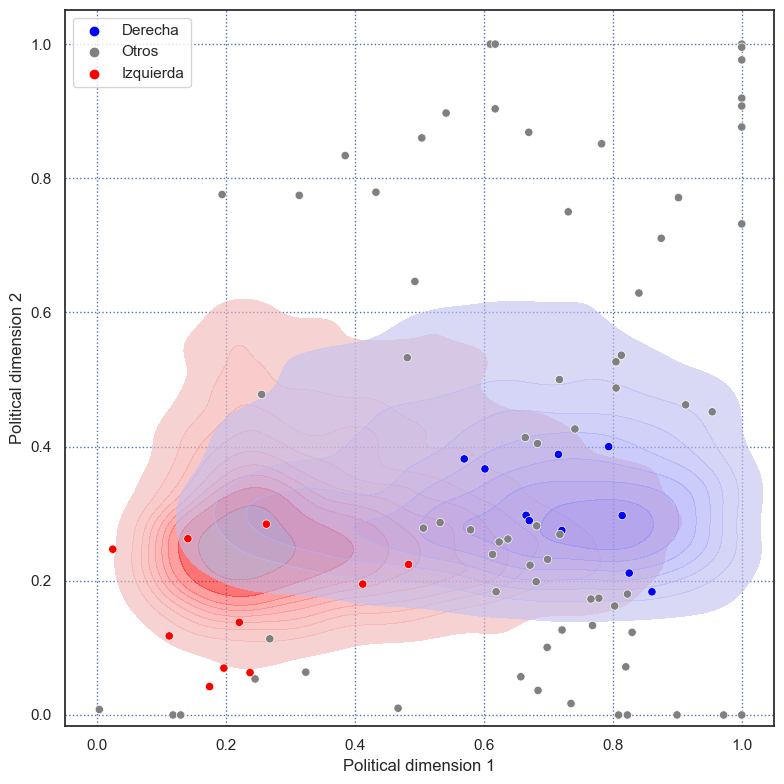

In [33]:

colores = ["red", "blue"]
iz = coordsU[(coordsU['politica'] >= 0) & (coordsU['politica'] <= 4)]
der = coordsU[(coordsU['politica'] >= 6) & (coordsU['politica'] <= 10)]
iz ['Political parties'] = 'Far-left [0,4]'
der ['Political parties'] = 'Far-right [6,10]'
extremos = pd.concat([iz,der],axis=0)

# Crear una figura y subgráficos
fig, axs = plt.subplots(figsize=(8, 8))

# Graficar el gráfico de densidad con jointplot
sns.kdeplot(data=extremos, x='z2', y='z1', hue='Political parties', palette=colores,
            fill=True, alpha=0.6, ax=axs)

# Graficar el gráfico de dispersión
scatter = sns.scatterplot(data=coordsP, x="z2", y="z1", hue='colors', palette=['blue', 'grey', 'red'], ax=axs)

# Personalizar leyenda con etiquetas
handles, labels = scatter.get_legend_handles_labels()
labels = ['Derecha', 'Otros', 'Izquierda']
axs.legend(handles=handles, labels=labels)

axs.set_xlabel('Political dimension 1')
axs.set_ylabel('Political dimension 2')

# Mostrar la figura
plt.xlim(-0.05,1.05)
plt.tight_layout()
plt.grid(color="b", linestyle="dotted", linewidth=1)
plt.show()



In [34]:
from matplotlib.lines import Line2D
def graficar_usuario_propuesta(coordsP,lista_iz,lista_der):
    # Crea un diccionario que mapee los nombres a 'square' (cuadrado) o 'diamond' (rombo)
    symbols_dict = {name: 'square' for name in lista_der}
    symbols_dict.update({name: 'diamond' for name in lista_iz})

    # Asigna 'circle' a los nombres que no están en las listas 'izquierda' ni 'derecha'
    symbols_dict.update({name: 'circle' for name in coordsP['short_name'] if name not in lista_iz and name not in lista_der})
    # Asigna 'circle' a los nombres que no están en las listas 'izquierda' ni 'derecha'
    coordsP['symbol'] = coordsP['short_name'].map(symbols_dict)

    # Define el tamaño de los símbolos
    symbol_size = [2 if symbol in ('square', 'diamond') else 0.5 for symbol in coordsP['symbol']]

    # Define los colores de los puntos como una nueva columna "colors" en coordsP
    coordsP['colors'] = ['blue' if symbol == 'square' else 'red' if symbol == 'diamond' else 'grey' for symbol in coordsP['symbol']]


    #Se agrega información de ranking
    coordsP['ranking'] = 'No ranking'

    for index, row in coordsP.iterrows():
        short_name = row['short_name']

        if short_name in lista_iz:
            coordsP.at[index, 'ranking'] = lista_iz.index(short_name)
        elif short_name in lista_der:
            coordsP.at[index, 'ranking'] = lista_der.index(short_name)

    coordsP = coordsP.sort_values(by='colors')

    colores = ["red", "blue"]
    iz = coordsU[(coordsU['politica'] >= 0) & (coordsU['politica'] <= 4)]
    der = coordsU[(coordsU['politica'] >= 6) & (coordsU['politica'] <= 10)]
    iz ['Political parties'] = 'Far-left [0,4]'
    der ['Political parties'] = 'Far-right [6,10]'
    extremos = pd.concat([iz,der],axis=0)

    # Crear una figura y subgráficos con tamaño fijo
    fig, axs = plt.subplots(figsize=(8, 8), gridspec_kw={'bottom': 0.15, 'left': 0.15, 'right': 0.85, 'top': 0.9})


    # Graficar el gráfico de densidad con jointplot
    sns.kdeplot(data=extremos, x='z2', y='z1', hue='Political parties', palette=colores,
                fill=True, alpha=0.6, ax=axs)

    # Graficar el gráfico de dispersión
    # Graficar el gráfico de dispersión
    scatter = sns.scatterplot(data=coordsP, x="z2", y="z1", hue='colors', palette=['blue', 'grey', 'red'], 
                          size='symbol', sizes={'circle': 50, 'square': 150, 'diamond': 150}, ax=axs)


    # Añadir texto con el nombre corto y el ranking a cada punto azul y rojo
    for index, row in coordsP.iterrows():
        short_name = row['short_name']
        ranking = row['ranking']
        x, y = row['z2'], row['z1']

        # Añadir texto solo a puntos azules y rojos
        if row['colors'] in ['blue', 'red']:
            # Ajusta el desplazamiento en x (puedes cambiar el valor según tus preferencias)
            x_offset = 0.02
            axs.text(x + x_offset, y, f'{ranking+1}', fontsize=10, ha='left', va='center')



    # Personalizar leyenda con etiquetas


    labels = ['Left','Right','Others']
    colors = ['red', 'blue', 'gray']
    handles = [Line2D([0], [0], marker='o', color=color, label=label, markersize=8,linestyle='None') for color, label in zip(colors, labels)]
    axs.legend(handles=handles, labels=labels)

    # Mostrar la figura
    plt.xlim(-0.05,1.05)
    plt.tight_layout()
    axs.axvline(x=0.5, color='gray', linestyle='--')
    
    plt.xlabel('Political Dimension 1')
    plt.ylabel('Political Dimension 2')
    # Dibujar una línea horizontal punteada en y=0.5
    axs.axhline(y=0.5, color='gray', linestyle='--')
    plt.show()

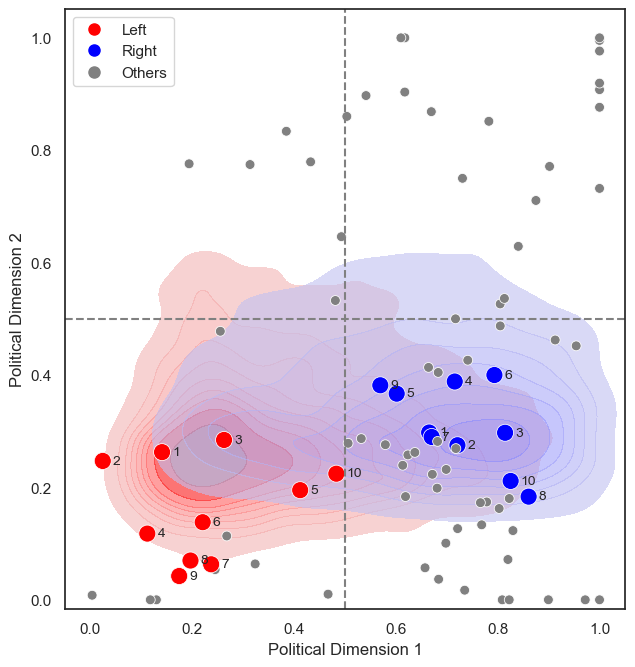

In [35]:
# Define la lista de nombres que deben tener el símbolo de cuadrado (square)
derecha_top10 = list(ranking_coords.sort_values("ranking_derecha_sort", ascending=True)['short_name_x'][0:10])

# Define la lista de nombres que deben tener el símbolo de rombo (diamond)
izquierda_top10 = list(ranking_coords.sort_values("ranking_izquierda_sort", ascending=True)['short_name_x'][0:10])

# Crear DataFrames para las listas
df_derecha = pd.DataFrame({'Propuesta': derecha_top10})
df_izquierda = pd.DataFrame({ 'Propuesta': izquierda_top10})
df_izquierda.index += 1  # Sumar uno a los índices
df_derecha.index += 1  # Sumar uno a los índices


graficar_usuario_propuesta(coordsP,izquierda_top10  ,derecha_top10 )

In [89]:
# Define la lista de nombres que deben tener el símbolo de cuadrado (square)
derecha_list_15 = list(ranking_coords.sort_values("ranking_derecha_sort", ascending=True)['short_name_x'][0:15])

# Define la lista de nombres que deben tener el símbolo de rombo (diamond)
izquierda_list_15 =list(ranking_coords.sort_values("ranking_izquierda_sort", ascending=True)['short_name_x'][0:15])

# Crea un diccionario que mapee los nombres a 'square' (cuadrado) o 'diamond' (rombo)
symbols_dict = {name: 'square' for name in derecha_list_15}
symbols_dict.update({name: 'diamond' for name in izquierda_list_15})

# Asigna 'circle' a los nombres que no están en las listas 'izquierda' ni 'derecha'
coordsP['symbol'] = coordsP['short_name'].map(symbols_dict)

# Define el tamaño de los símbolos
symbol_size = [2 if symbol in ('square', 'diamond') else 0.5 for symbol in coordsP['symbol']]

# Define los colores de los puntos como una nueva columna "colors" en coordsP
coordsP['colors'] = ['blue' if symbol == 'square' else 'red' if symbol == 'diamond' else 'grey' for symbol in coordsP['symbol']]

#Se agrega información de ranking
coordsP['ranking'] = 'No ranking'

for index, row in coordsP.iterrows():
    short_name = row['short_name']
    
    if short_name in izquierda_list_15:
        coordsP.at[index, 'ranking'] = izquierda_list_15.index(short_name)
    elif short_name in derecha_list_15:
        coordsP.at[index, 'ranking'] = derecha_list_15.index(short_name)
        
# Crea el gráfico de dispersión personalizado
fig = px.scatter(coordsP, x="z2", y="z1", color = 'colors',color_discrete_sequence=["blue","grey","red"], hover_data=["short_name",'ranking'], size=symbol_size)

# Personaliza la etiqueta de la leyenda
label =['Derecha','Otro','Izquierda']
for i,trace in enumerate(fig.data):
    trace.name = label[i]
    
# Personaliza el diseño del gráfico
fig.update_layout(
    title="Gráfico de Dispersión Top 15",
    xaxis_title="z1",
    yaxis_title="z2",
    legend_title="Topic"

)

# Ajustar el tamaño de la leyenda y ubicarla a la derecha
fig.update_layout(
    legend=dict(
        itemsizing='constant',  # Ajusta el tamaño de los elementos de la leyenda
        orientation="v",  # Cambia la orientación de la leyenda a vertical
        yanchor="top",  # Ancla la leyenda en la parte superior
        y=1,  # Ajusta la posición vertical de la leyenda
        xanchor="left",  # Ancla la leyenda a la izquierda
        x=1.02  # Ajusta la posición horizontal de la leyenda
    )
)
# Establec6r el tamaño del gráfico para que sea cuadrado sin considerar la leyenda
fig.update_layout(
    autosize=False,
    width=700,  # Ajusta según tus preferencias
    height=600  # Ajusta según tus preferencias
)
# Muestra el gráfico interactivo
fig.show()


offline.plot(fig, filename='results/figures/Propuestas_notebook_modificado_top15_preferencias.html')

'results/figures/Propuestas_notebook_modificado_top15_preferencias.html'

In [90]:
# Crea un diccionario que mapee los nombres a 'square' (cuadrado) o 'diamond' (rombo)
symbols_dict = {name: 'square' for name in derecha_list_15}
symbols_dict.update({name: 'diamond' for name in izquierda_list_15})

# Asigna 'circle' a los nombres que no están en las listas 'izquierda' ni 'derecha'
symbols_dict.update({name: 'circle' for name in coordsP['short_name'] if name not in izquierda_list_15 and name not in derecha_list_15})

# Asigna el símbolo correspondiente a la columna "symbol" en tu DataFrame
coordsP['symbol'] = coordsP['short_name'].map(symbols_dict)

#Se agrega información de ranking
coordsP['ranking'] = 'No ranking'

for index, row in coordsP.iterrows():
    short_name = row['short_name']
    
    if short_name in izquierda_list_15:
        coordsP.at[index, 'ranking'] = izquierda_list_15.index(short_name)
    elif short_name in derecha_list_15:
        coordsP.at[index, 'ranking'] = derecha_list_15.index(short_name)

# Crea la aplicación Dash
app = dash.Dash(__name__)

# Define el diseño de la aplicación
app.layout = html.Div([
     html.H1("Selecciona un tipo de gráfico:"),
    dcc.Dropdown(
        id='symbol-dropdown',
        options=[
            {'label': 'Preferencia Derecha', 'value': 'square'},
            {'label': 'Preferencia Izquierda', 'value': 'diamond'},
            {'label': 'Otros', 'value': 'circle'}
        ],
        value='square'  # Valor inicial
    ),
    dcc.Graph(id='scatter-plot')
])




# Define una función que actualiza el gráfico cuando cambia la selección en el menú desplegable
@app.callback(
    Output('scatter-plot', 'figure'),
    Input('symbol-dropdown', 'value')
)


# Define una función que actualiza el gráfico según el tipo seleccionado

    
def update_scatter_plot(selected_symbol):
    # Crea un diccionario para mapear las etiquetas a los símbolos
    symbol_dict = {
        'Cuadrados': 'square',
        'Rombos': 'diamond',
        'Círculos': 'circle'
    }
    
    if selected_symbol == 'square':
        # Define los colores de los puntos como una nueva columna "colors" en coordsP
        coordsP['colors'] = ['blue' if symbol == 'square' else 'red' if symbol == 'diamond' else 'grey' for symbol in coordsP['symbol']]
        symbol_size = [3 if symbol in ('square') else 0.5 for symbol in coordsP['symbol']]
        # Crea el gráfico de dispersión personalizado
        fig = px.scatter(coordsP, x="z2", y="z1", color = 'colors',color_discrete_sequence=["blue","grey",'red'], hover_data=["short_name",'ranking'], size=symbol_size)
        label =['Derecha','Otro','Izquierda']
        for i,trace in enumerate(fig.data):
            trace.name = label[i]
    elif selected_symbol =='diamond':
        symbol_size = [3 if symbol in ('diamond') else 0.5 for symbol in coordsP['symbol']]
        # Define los colores de los puntos como una nueva columna "colors" en coordsP
        coordsP['colors'] = ['blue' if symbol == 'square' else 'red' if symbol == 'diamond' else 'grey' for symbol in coordsP['symbol']]

        # Crea el gráfico de dispersión personalizado
        fig = px.scatter(coordsP, x="z2", y="z1", color = 'colors',color_discrete_sequence=["blue","grey","red"], hover_data=["short_name",'ranking'], size=symbol_size)
        label =['Derecha','Otro','Izquierda']
        for i,trace in enumerate(fig.data):
            trace.name = label[i]
    
    else:

        coordsP['colors'] = ['blue' if symbol == 'square' else 'red' if symbol == 'diamond' else 'grey' for symbol in coordsP['symbol']]

        # Crea el gráfico de dispersión personalizado
        fig = px.scatter(coordsP, x="z2", y="z1", color = 'colors',color_discrete_sequence=['blue',"grey","red"], hover_data=["short_name",'ranking'])
        label =['Izquierda','Otro','Derecha']
        for i,trace in enumerate(fig.data):
            trace.name = label[i]

    #Personaliza el diseño del gráfico
    fig.update_layout(
        title="Gráfico de Dispersión con Información al Pasar el Mouse",
        xaxis_title="z1",
        yaxis_title="z2",
        legend_title="Topic Name"
    )

        
    # Establece límites en los ejes x e y
    fig.update_xaxes(range=[-0.06,1.06])
    fig.update_yaxes(range=[-0.06,1.06])
    #fig.update_traces(customdata=coordsP['ranking'], hovertemplate="Short Name: %{customdata}<br>Ranking: %{text}")
    
    # Ajustar el tamaño de la leyenda y ubicarla a la derecha
    fig.update_layout(
        legend=dict(
            itemsizing='constant',  # Ajusta el tamaño de los elementos de la leyenda
            orientation="v",  # Cambia la orientación de la leyenda a vertical
            yanchor="top",  # Ancla la leyenda en la parte superior
            y=1,  # Ajusta la posición vertical de la leyenda
            xanchor="left",  # Ancla la leyenda a la izquierda
            x=1.02  # Ajusta la posición horizontal de la leyenda
        )
    )
    # Establec6r el tamaño del gráfico para que sea cuadrado sin considerar la leyenda
    fig.update_layout(
        autosize=False,
        width=700,  # Ajusta según tus preferencias
        height=600  # Ajusta según tus preferencias
    )


    
    fig.write_html("results/figures/Propuestas_notebook_modificado_top5_preferencias.html")
    return fig

if __name__ == '__main__':
    app.run_server(debug=True,port=8095)

In [91]:
# Crea la aplicación Dash
app1 = dash.Dash(__name__)

# Obtiene los valores únicos de 'short_name' desde tus datos
unique_short_names = coordsP['short_name'].unique()

# Crea una lista de opciones para el menú desplegable
dropdown_options = [{'label': short_name, 'value': short_name} for short_name in unique_short_names]

# Define el diseño de la aplicación
app1.layout = html.Div([
    html.H1("Selecciona un tipo de gráfico:"),
    dcc.Dropdown(
        id='symbol-dropdown',
        options=dropdown_options,
        value=unique_short_names[0]  # Valor inicial
    ),
    dcc.Graph(id='scatter-plot')
])

# Define una función que actualiza el gráfico cuando cambia la selección en el menú desplegable
@app1.callback(
    Output('scatter-plot', 'figure'),
    Input('symbol-dropdown', 'value')
)

# Define una función que actualiza el gráfico según el tipo seleccionado
def update_scatter_plot(selected_symbol):
    A = coordsP.copy()
    # Define los colores de los puntos como una nueva columna "colors" en coordsP
    A['colors'] = ['blue' if symbol == 'square' else 'red' if symbol == 'diamond' else 'grey' for symbol in A['symbol']]
    A['colors'][A['short_name'] == selected_symbol]='green'
    A= A.sort_values('colors')
    name =  A['name'][A['short_name'] == selected_symbol].iloc[0]

    symbol_size = [3 if symbol in ('green') else 0.5 for symbol in A['colors']]
    # Crea el gráfico de dispersión personalizado
    fig = px.scatter(A, x="z2", y="z1", color = 'colors',color_discrete_sequence=['blue','green',"grey","red"], hover_data=["short_name",'ranking'], size=symbol_size)
    label =['Derecha',selected_symbol,'Otro','Izquierda']
    for i,trace in enumerate(fig.data):
        trace.name = label[i]
        
    annotation_text = f"<b>Nombre: {name}</b>"
    
    
     # Añade la anotación al gráfico
    fig.update_layout(
        annotations=[
            dict(
                x=0,
                y=-0.15,
                xref="paper",
                yref="paper",
                showarrow=False,
                text=annotation_text,
                font=dict(size=12, color="black")
            )
        ]
    )
        
          
    # Personaliza el diseño del gráfico
    fig.update_layout(
        title="Gráfico de Dispersión con Información al Pasar el Mouse",
        xaxis_title="z1",
        yaxis_title="z2",
        legend_title="name"
    )

    # Ajustar el tamaño de la leyenda y ubicarla a la derecha
    fig.update_layout(
        legend=dict(
            itemsizing='constant',  # Ajusta el tamaño de los elementos de la leyenda
            orientation="v",  # Cambia la orientación de la leyenda a vertical
            yanchor="top",  # Ancla la leyenda en la parte superior
            y=1,  # Ajusta la posición vertical de la leyenda
            xanchor="left",  # Ancla la leyenda a la izquierda
            x=1.02  # Ajusta la posición horizontal de la leyenda
        )
    )
    # Establec6r el tamaño del gráfico para que sea cuadrado sin considerar la leyenda
    fig.update_layout(
        autosize=False,
        width=800,  # Ajusta según tus preferencias
        height=600  # Ajusta según tus preferencias
    )

    # Establece límites en los ejes x e y
    fig.update_xaxes(range=[-0.05,1.05])
    fig.update_yaxes(range=[-0.05,1.05])
    

    fig.write_html("results/figures/Propuestas_notebook_modificado_top5_preferencias.html")
    return fig



if __name__ == '__main__':
    app1.run_server(debug=True,port=8095)
